# **Tutorial: Quality Control (QC) and Filtering Analysis of 10x Genomics Epi Multiome Data**




Welcome to the Epi Multiome ATAC + Gene Expression quality control (QC) and filtering analysis guide, designed to help you continue your data analysis journey after running Cell Ranger ARC.

This tutorial explores QC strategies for Epi Multiome data that are already processed with Cell Ranger ARC, with a focus on the ATAC data analysis. These strategies are demonstrated using a [10x Genomics public dataset](https://www.10xgenomics.com/datasets/pbmc-from-a-healthy-donor-no-cell-sorting-3-k-1-standard-2-0-0) ([web summary](https://cf.10xgenomics.com/samples/cell-arc/2.0.0/pbmc_unsorted_3k/pbmc_unsorted_3k_web_summary.html)). The goal is not to prescribe a strict protocol for analysis, but instead to help you understand some useful tricks and tips to look at your own data.

## **1. Installation of R packages**

The following code will install the required library dependency packages for this QC tutorial. Run each code block shown below. There are two required steps:

*   Install some dependencies from a pre-packaged file (R_packages.tar.gz), which takes about 1-2 min.
*   Next, install extra dependencies separately, which takes about 15 min.

These two installation steps together below may take about 20-30 min.

The [Signac](https://stuartlab.org/signac/) and the [biovizBase](https://www.bioconductor.org/packages//2.13/bioc/html/biovizBase.html) package from [Bioconductor](https://www.bioconductor.org/) are installed separately during the second step.

If you would like to install these packages on your own system, click on "Show code" to see the steps required to install each package individually. You must also remove the `#` comment character at the beginning of each line. If you choose to install the packages individually, the process may take about 1-2 hours depending on the resource capacity of your system.

In [1]:
# @title
#if (!requireNamespace("remotes", quietly = TRUE))
    install.packages("remotes")
#install.packages("devtools")
#install.packages("tidyverse")
#install.packages("cowplot")
#install.packages("patchwork")
#install.packages("stringr")
#install.packages("dplyr")
#install.packages("Matrix")
#install.packages("ggplot2")
#remotes::install_version(package = 'Seurat', version = package_version('5.3.1'), dependencies = TRUE)
#remotes::install_version(package = 'Signac', version = package_version('1.16.0'), dependencies = TRUE)

#if (!require("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")

#BiocManager::install("EnsDb.Hsapiens.v86")
#BiocManager::install("BSgenome.Hsapiens.UCSC.hg38")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



This step can take 2-5 min.

In [2]:
# download R_packages from file
system("wget https://cf.10xgenomics.com/supp/cell-arc/analysis_guide/R_packages.tar.gz")

# move all pre-installed R packages to default R folder path
system("tar -xzvf /content/R_packages.tar.gz")
system(paste0("mv /content/R_packages/* ", .libPaths()[1]))

This step can take 15-20 min.

In [3]:
install.packages("Signac")
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install("biovizBase")
BiocManager::install('glmGamPoi')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'biovizBase'

also installing the dependencies ‘checkmate’, ‘htmlTable’, ‘colorspace’, ‘Formula’, ‘Hmisc’, ‘dichromat’, ‘VariantAnnotation’


Old packages: 'arrow', 'BH', 'dplyr', 'e1071', 'fastmatch', 'fitdistrplus',
  'futile.logger', 'future', 'future.apply', 'GenomicRanges', 'ggplot2',
  'ggrepel', 'ggseqlogo', 'globals', 'igraph', 'irlba', 'leidenbase',
  'listenv', 'lsa', 'mnormt', 'multcomp', 'mvtnorm', 'parallelly', 'plotly',
  'plotrix', 'proxy', 'rbibutils', 'RcppAnnoy', 'RcppArmadillo',
  'RcppParallel', 'Rdpack', 'reticulate', 'Rfast2', 'robustbase', 'ROCR',
  'RSQLite', 'rtracklayer', 'sctransform', 'segmented'

After installation, load each of the required libraries for this tutorial.

In [4]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(Signac)
    library(Seurat)
    library(EnsDb.Hsapiens.v86)
    library(BSgenome.Hsapiens.UCSC.hg38)
    library(ggplot2)
    library(Matrix)
    library(dplyr)
    library(stringr)
    library(patchwork)
    library(cowplot)
    })

## **2. Load required input files**

This guide uses five key files from the Cell Ranger ARC pipeline outputs. You can find more information about each of these files on the ["Understanding Outputs" page for Cell Ranger ARC on the 10x Support website](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/outputs/understanding-output).

* Filtered feature-barcode matrix H5 file
* Fragments TSV GZ file
* Fragments TSV GZ TBI file
* Per-barcode metrics CSV file
* Cell annotation CSV file

Download and list the required files.


In [5]:
system("wget https://cf.10xgenomics.com/supp/cell-arc/analysis_guide/multiome_qc_analysis_guide_inputs.tar.gz")
system("tar -xzvf /content/multiome_qc_analysis_guide_inputs.tar.gz")
list.files("/content/")

[1] "atac_fragments.tsv.gz"                   
[2] "atac_fragments.tsv.gz.tbi"               
[3] "cell_types"                              
[4] "filtered_feature_bc_matrix.h5"           
[5] "multiome_qc_analysis_guide_inputs.tar.gz"
[6] "per_barcode_metrics.csv"                 
[7] "R_packages"                              
[8] "R_packages.tar.gz"                       
[9] "sample_data"

Import the h5 matrix file and set the fragments filename and path location.

In [6]:
multiome_data = Read10X_h5("/content/filtered_feature_bc_matrix.h5")
frag_file = "/content/atac_fragments.tsv.gz"

Genome matrix has multiple modalities, returning a list of matrices for this genome



The filtered feature-barcode matrix file includes a gene expression count matrix for the RNA data and a peaks count matrix for the ATAC data. Observe that this dataset has 3031 barcodes, 81157 peaks, and 36601 genes.

In [7]:
print(dim(multiome_data$`Peaks`))
print(dim(multiome_data$`Gene Expression`))

[1] 81157  3031
[1] 36601  3031


The `per_barcode_metrics.csv` file contains several useful QC metrics associated with each barcode. See our [support page](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/outputs/per-barcode-qc-metrics) for detailed information about each column.

In [8]:
per_bc_metrics = data.frame(read_csv("/content/per_barcode_metrics.csv",show_col_types=FALSE))
head(per_bc_metrics)

,barcode,gex_barcode,atac_barcode,is_cell,excluded_reason,gex_raw_reads,gex_mapped_reads,gex_conf_intergenic_reads,gex_conf_exonic_reads,gex_conf_intronic_reads,⋯,atac_raw_reads,atac_unmapped_reads,atac_lowmapq,atac_dup_reads,atac_chimeric_reads,atac_mitochondrial_reads,atac_fragments,atac_TSS_fragments,atac_peak_region_fragments,atac_peak_region_cutsites
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AAACAGCCAAACAACA-1,AAACAGCCAAACAACA-1,ACAGCGGGTGTGTTAC-1,0,0,0,0,0,0,0,⋯,6,0,0,0,0,0,6,4,5,9
2,AAACAGCCAAACCCTA-1,AAACAGCCAAACCCTA-1,ACAGCGGGTAACAGGC-1,0,0,0,0,0,0,0,⋯,4,2,0,0,0,0,2,2,1,2
3,AAACAGCCAAACCTAT-1,AAACAGCCAAACCTAT-1,ACAGCGGGTGCGCGAA-1,0,0,315,276,19,223,6,⋯,36,7,3,3,0,14,9,1,1,1
4,AAACAGCCAAACCTTG-1,AAACAGCCAAACCTTG-1,ACAGCGGGTCCTCCAT-1,0,2,36,35,0,34,1,⋯,2,0,0,1,0,0,1,0,0,0
5,AAACAGCCAAACGGGC-1,AAACAGCCAAACGGGC-1,ACAGCGGGTAGGTGAC-1,0,0,5,5,0,5,0,⋯,0,0,0,0,0,0,0,0,0,0
6,AAACAGCCAAACTAAG-1,AAACAGCCAAACTAAG-1,ACAGCGGGTTACCCAG-1,0,2,20,20,0,20,0,⋯,1,0,0,0,0,0,1,0,0,0


The `cell_types.csv` file contains cell annotations from Cell Ranger ARC's automated cell annotation algorithm. See [this page](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/outputs/cr-arc-cell-annotation-outputs) for detailed information about each column.

In [9]:
cell_types = read_csv("/content/cell_types/cell_types.csv",show_col_types=FALSE)
head(cell_types)

barcode,coarse_cell_type,fine_cell_type,cell_count_in_model,coarse_cell_type_unfiltered,umi_count
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
AAACAGCCAACAGGTG-1,T cell,"CD4-positive, alpha-beta T cell",410,T cell,1796
AAACATGCAACAACAA-1,monocyte,monocyte,194,monocyte,3997
AAACATGCACCTGGTG-1,T cell,"CD4-positive, alpha-beta T cell",121,T cell,460
AAACCAACACAGCCTG-1,T cell,"CD4-positive, alpha-beta T cell",442,T cell,1565
AAACCAACAGCAAGAT-1,T cell,"CD4-positive, alpha-beta T cell",385,T cell,1574
AAACCAACATTGCGAC-1,T cell,"CD4-positive, alpha-beta T cell",400,T cell,1688


This analysis will focus on the `coarse_cell_types`. Observe below that a small fraction of cells are annotated as cell types that are not found in PBMCs, e.g., glial cells and neuron-associated cells. These have not been annotated correctly. To address this for now, mark these cell types as `other` if there are fewer than 50 cells annotated with a given cell type. However, users are encouraged to use these annotations as a starting point to further refine their cell typing in [Loupe Browser](https://www.10xgenomics.com/support/software/loupe-browser/latest). Also note the presence of the `Low UMI Barcode` annotation. In Epi Multiome data, a barcode may be called as a cell if it has sufficient ATAC data, even if it does not have much RNA data. Since RNA data alone is used for annotations, these cells will not be annotated correctly.

In [10]:
frequency_table = table(cell_types["coarse_cell_type"])
frequency_table

coarse_cell_type
                B cell             glial cell            granulocyte 
                   290                     22                      1 
    hematopoietic cell              leukocyte        Low UMI Barcode 
                     9                    338                     17 
            lymphocyte             macrophage               monocyte 
                    92                     81                    966 
      mononuclear cell      myeloid leukocyte neuron associated cell 
                    31                      4                      1 
                T cell 
                  1179 

In [11]:
low_cell_count_annotations = names(frequency_table)[frequency_table<50]
cell_types <- cell_types %>%
    mutate(
        coarse_cell_type = if_else(
            coarse_cell_type %in% low_cell_count_annotations,
            "Other",
             coarse_cell_type
        ),
    )

## **3. Create Seurat object**

This tutorial uses [Seurat](https://satijalab.org/seurat/), a well-established package for single cell genomics analysis, along with [Signac](https://stuartlab.org/signac/), a package for analysis of single cell chromatin accessibility data, such as single cell ATAC-seq. The code below follows the [pbmc_multiomic tutorial from Signac](https://stuartlab.org/signac/articles/pbmc_multiomic) to create a multiome object containing both data modalities. This step may take a few minutes.

In [12]:
# get gene annotations for hg38
annotation <- suppressWarnings(GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86))
seqlevelsStyle(annotation) <- "UCSC"

# create a Seurat object containing the RNA data
pbmc <- CreateSeuratObject(
  counts = multiome_data$`Gene Expression`,
  assay = "RNA"
)

# create ATAC assay and add it to the object
pbmc[["ATAC"]] <- CreateChromatinAssay(
  counts = multiome_data$Peaks,
  sep = c(":", "-"),
  fragments = frag_file,
  annotation = annotation,
)

Computing hash



## **4. Explore metrics for ATAC-Seq quality control**

A key difference between the gene expression and ATAC-seq count matrices is the nature of their feature sets. Gene expression uses a reference set of genes as features, while ATAC-seq features are peaks that are dynamically inferred from each dataset. It is therefore important to assess the quality of data both at the level of individual barcodes as well as individual peaks.


### **4.1 Barcode-level quality control**

This section explores several metrics commonly used in the field to assess data quality at the level of individual barcodes:

* ATAC fragment count
* Fraction fragments overlapping peaks (Peak targeting)
* Fraction fragments overlapping TSS (TSS targeting)
* TSS Enrichment
* Nucleosome Signal
* Number of Gene Expression UMIs

While it is common practice to set independent thresholds for each metric, these values are often correlated. This tutorial demonstrates that filtering based on ATAC fragment counts, peak targeting, and the number of gene expression UMIs is sufficient to identify high quality barcodes for this specific dataset. Users are encouraged to examine these metrics in their own datasets to determine appropriate thresholds and filtering strategies.

A supplemental notebook is provided for this tutorial to further explore how these variables relate to one another, which is an [interactive joint visualization of these common quality control metrics](https://colab.research.google.com/github/10XGenomics/analysis_guides/blob/main/Epi_multiome_QC_interactive_visualization.ipynb).

The following sections define each metric and visualize their distributions. The final filters are applied to the dataset in Section 4.1.6 (Putting it all together).

#### **4.1.1 ATAC fragment count and Fraction fragments overlapping peaks (Peak targeting)**

Begin your QC journey by evaluating whether each barcode in your filtered feature barcode matrix represents a high-quality, viable cell.

1. Does the barcode have a sufficient quantity of data?

    To answer this question, look at the total **ATAC fragment count**. The [cell calling algorithm in Cell Ranger ARC](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/algorithms-overview/calling-cell-barcodes) uses paired count data from both the gene expression and ATAC libraries to determine whether a barcode is a cell barcode. This may result in cell barcodes that have high gene expression signal but low ATAC signal. You may want to filter these low ATAC signal barcodes from downstream analysis.

2. How much of the data comes from open regions of chromatin?

    This is captured by the **fraction fragments overlapping peaks**.
    
    In ATAC-seq, a **peak** is a region of the genome with a high accumulation of fragment ends. These pile-ups of data indicate areas where the chromatin was open and accessible to the transposase enzyme. Biologically, these peaks usually correspond to functional DNA elements such as promoters, enhancers, suppressors, etc.
  
    High-quality barcodes have a high fraction of fragments overlapping peaks, indicating that a high fraction of the ATAC data is concentrated in these biologically relevant areas. Reasons for a low fraction of fragments overlapping peaks can include:

    - Non-specific background tagmentation: While the transposase enzyme preferentially binds and cuts open chromatin, it can occasionally cut in closed regions, resulting in background signal.
    - Loss of nucleosome structure: If the nucleosome structure of the DNA in a cell is lost, for example, in dead/dying cells or [granulocytes participating in NETosis](https://kb.10xgenomics.com/s/article/360046631331-How-do-granulocytes-affect-my-ATAC-standalone-or-Multiome-data#:~:text=Answer:%20Granulocytes%2C%20specifically%20neutrophils%2C,with%20lots%20of%20open%20chromatin.), the DNA becomes globally accessible. In this case, the transposase enzyme cuts randomly across the entire genome, instead of targeting specific features. These barcodes will typically have a high ATAC fragment count and low peak targeting.

    While Cell Ranger ARC includes a conservative low-targeting filter (see our [support page on calling cell barcodes](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/algorithms-overview/calling-cell-barcodes)), you can apply more stringent thresholds tailored to your specific dataset.

The `per_barcode_metrics.csv` file that you previously loaded includes both the total number of fragments and the number of fragments per barcode that are in peaks. Next, add this to your Seurat metadata for easy visualization.

In [13]:
rownames(per_bc_metrics) = per_bc_metrics$barcode
# the per barcode metrics file contains information about both cell and non-cell barcodes. Here we subset to cell barcodes only.
cell_bc_metrics = per_bc_metrics[per_bc_metrics$is_cell==1,]
cell_bc_metrics$frac_fragments_in_peaks = cell_bc_metrics$atac_peak_region_fragments / cell_bc_metrics$atac_fragments
pbmc <- AddMetaData(pbmc, metadata = cell_bc_metrics)

The following code plots the relationship between the number of ATAC fragments per barcode and the fraction of fragments overlapping peaks.

The red lines in the plot below are proposed heuristics for filtering out barcodes with low count or low peak targeting. These heuristics may be a useful starting point for further tuning these thresholds for specific datasets.

[1] "Percentage of barcodes marked for filtering:"
[1] 4.7839


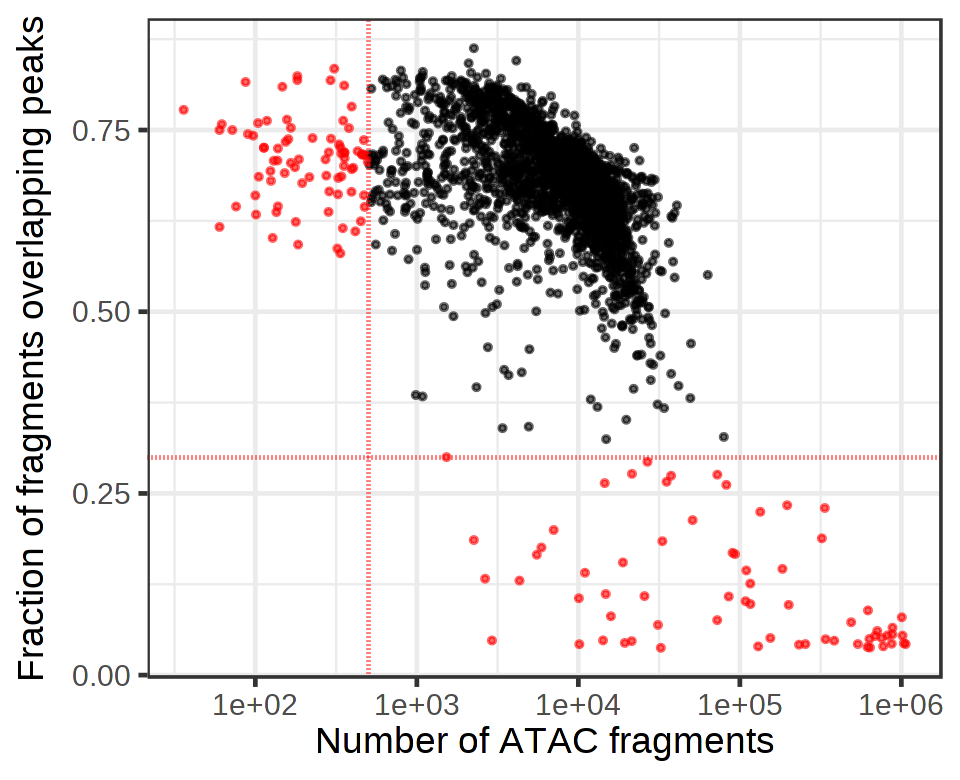

In [14]:
options(repr.plot.width = 8, repr.plot.height = 6.5)

low_fragment_count_threshold = 500 # Threshold for number of ATAC fragments
low_peak_targeting_threshold = 0.3 # Threshold for fraction ATAC fragments in peaks.

pbmc@meta.data$low_count = pbmc@meta.data$atac_fragments<low_fragment_count_threshold
pbmc@meta.data$low_peak_targeting = pbmc@meta.data$frac_fragments_in_peaks<low_peak_targeting_threshold
pbmc@meta.data$low_count_or_low_peak_targeting = pbmc@meta.data$atac_fragments<low_fragment_count_threshold | pbmc@meta.data$low_peak_targeting

print("Percentage of barcodes marked for filtering:")
print(100*sum(pbmc@meta.data$low_count_or_low_peak_targeting) / nrow(pbmc@meta.data))

ggplot(pbmc@meta.data,aes(x=atac_fragments ,y=frac_fragments_in_peaks,color = low_count_or_low_peak_targeting))+
    geom_point(size=1,alpha=0.6) +
    scale_x_continuous(trans='log10')+
    scale_color_manual(values=c("black","red"))+
    geom_vline(xintercept = low_fragment_count_threshold, linetype = "dotted", color = "red")+
    geom_hline(yintercept=low_peak_targeting_threshold, linetype = "dotted", color = "red")+
    theme_bw(base_size=22)+xlab("Number of ATAC fragments") + ylab("Fraction of fragments overlapping peaks")+NoLegend()

#### **4.1.2 Fraction fragments overlapping TSS (TSS targeting)**

A metric that is closely related to `fraction fragments overlapping peaks` is the `fraction fragments overlapping TSS (Transcription Start Sites)`. Unlike peak locations, which are inferred from specific datasets, Transcription Start Sites (TSS) for each gene have fixed positions on the reference. This consistency can make metrics that use TSS easier to interpret and compare across different datasets.

Some interesting observations from the plot below are:
1. `Fraction fragments overlapping peaks` and `fraction fragments overlapping TSS` are highly correlated with each other. Barcodes that do not meet the previously defined low peak targeting threshold are colored in red. Observe that these are the same barcodes that have low TSS targeting.
2. Since the TSS locations are typically subsets of all peak locations, for any given barcode, the `fraction fragments overlapping TSS` is typically lower than the `fraction fragments overlapping peaks`.
3. There are two distinct cell populations. This is common for PBMC samples that are composed of diverse cell types.

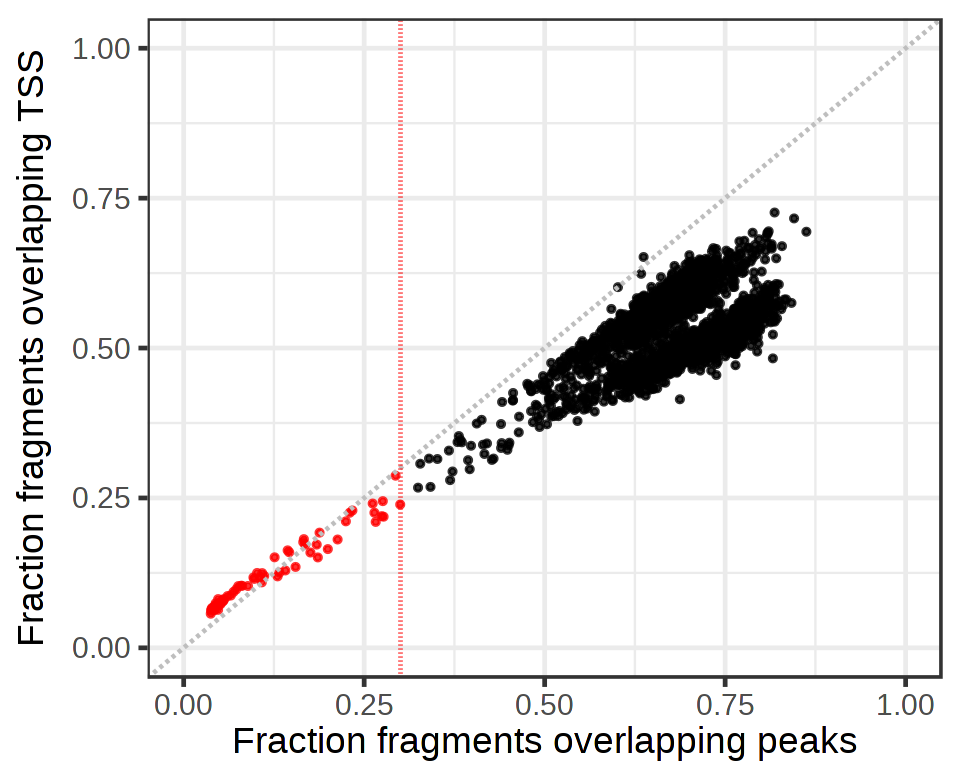

In [15]:
pbmc@meta.data$frac_fragments_tss = pbmc@meta.data$atac_TSS_fragments / pbmc@meta.data$atac_fragments
ggplot(pbmc@meta.data,aes(x=frac_fragments_in_peaks ,y=frac_fragments_tss,color = low_peak_targeting))+
    geom_point(size=1,alpha=0.8) +
    scale_color_manual(values=c("black","red"))+
    geom_abline(slope=1,intercept=0,linetype="dashed",color="grey")+  # x=y reference line
    geom_vline(xintercept=low_peak_targeting_threshold, linetype = "dotted", color = "red")+ # low targeting filter line
    theme_bw(base_size=22)+xlim(0,1)+ylim(0,1)+ylab("Fraction fragments overlapping TSS")+xlab("Fraction fragments overlapping peaks")+NoLegend()

To test the hypothesis that the two populations in the plot above represent distinct cell types, look at the cell annotations from [Cell Ranger's automated cell annotation pipeline](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/running-pipelines/cr-arc-cell-annotation-pipeline). You have already loaded the `cell_types.csv` file, so now you can add this to the Seurat metadata and visualize it.

In [16]:
pbmc <- AddMetaData(object = pbmc,metadata = cell_types$coarse_cell_type, col.name = "cell_type")

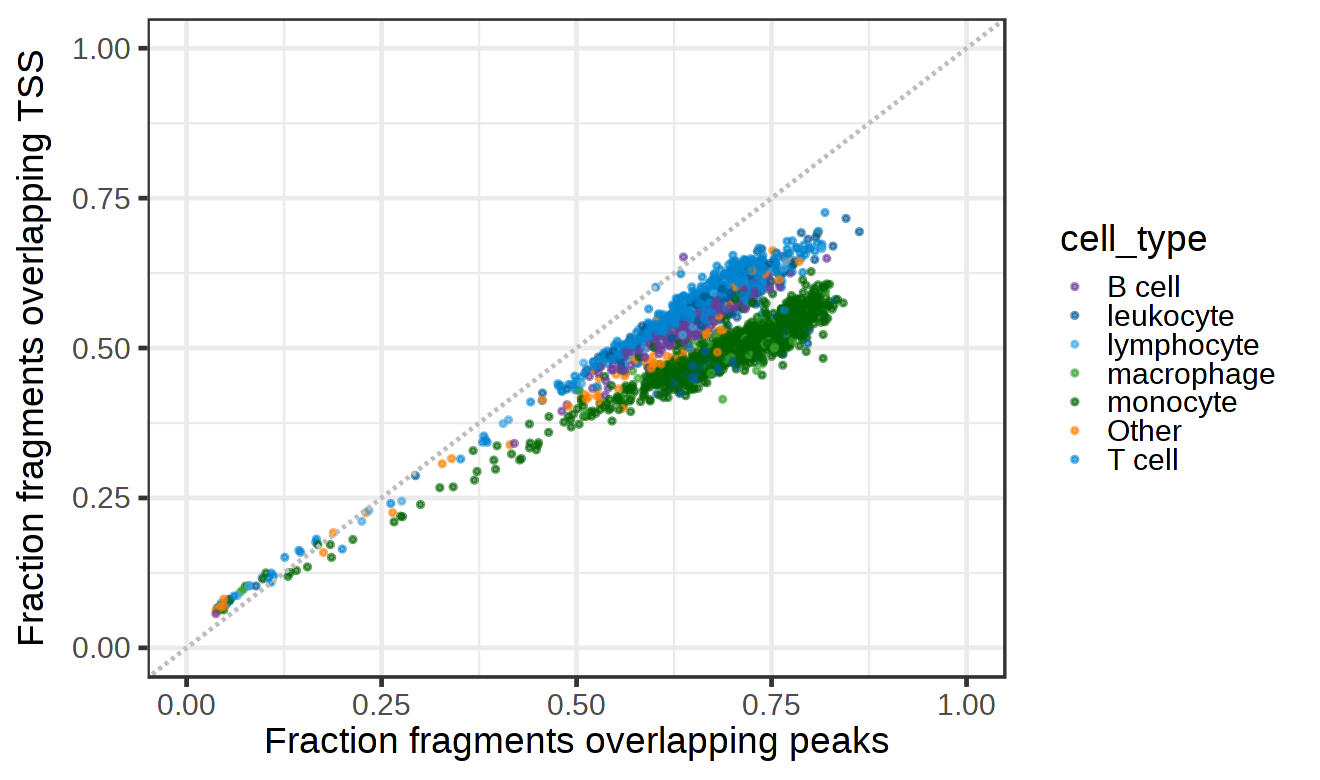

In [17]:
options(repr.plot.width = 11, repr.plot.height = 6.5)

custom_domain <- c(
  'T cell',
  'lymphocyte',
  'leukocyte',
  'B cell',
  'monocyte',
  'macrophage',
  'Other'
)

custom_color <- c(
  '#0084D1',
  '#40A4E0',
  '#005B94',
  '#6A3D9A',
  '#006400',
  '#33A02C',
  '#FF7F00'
)

color_mapping <- setNames(custom_color, custom_domain)

ggplot(pbmc@meta.data,aes(x=frac_fragments_in_peaks ,y=frac_fragments_tss))+
    geom_point(size=0.8,alpha=0.6,aes(color=cell_type)) +
    geom_abline(slope=1,intercept=0,linetype="dashed",color="gray")+
    theme_bw(base_size=22)+xlim(0,1)+ylim(0,1)+ylab("Fraction fragments overlapping TSS")+xlab("Fraction fragments overlapping peaks")+
    scale_color_manual(values=color_mapping)

In the plot above, you can clearly see a separation of the T and B cells from the monocyte subsets, confirming the hypothesis that the distinct populations arose from distinct cell types.

Note: TSS targeting is only a useful metric to compare datasets when high-quality TSS annotations are available. In the absence of reliable annotations, users should prioritize peak-based metrics. To compare datasets with different peak sets, it is recommended to reprocess the data through Cell Ranger ARC using a common peak set.

#### **4.1.3. TSS Enrichment**

TSS Enrichment is a measure of signal-to-noise at the TSS regions, calculated as the ratio of the number of fragments in the TSS to the number of fragments in the regions flanking the TSS. In general, higher values of TSS enrichment indicate cleaner data.

While the per-barcode TSS enrichment is sometimes used as a QC metric in the field, the inherent sparsity of single cell ATAC-seq data can make this metric noisy. In barcodes with very low total fragment counts, a small number of random fragments falling into a TSS region by chance can artificially inflate the ratio. This creates spuriously high enrichment values that do not actually reflect high data quality. Because of this, while TSS enrichment can be reliable when assessing the quality of the bulk sample by pooling together data from all cells, 10x Genomics does not generally advocate for using this as a filtering metric at the single-barcode level.

Use the [Signac package](https://stuartlab.org/signac/reference/tssenrichment) to calculate the per-barcode TSS Enrichment. This step may take a 3-5 minutes.

In [18]:
DefaultAssay(pbmc) <- "ATAC"
pbmc <- TSSEnrichment(pbmc)

Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score



The plot below shows the relationship between the per-barcode TSS enrichment and ATAC fragment count. As previously noted, observe the barcodes on the far right side of the plot with extremely high TSS enrichment values > 30 but low fragment counts, strongly suggesting that these high enrichment values may be spurious.

The barcodes that do not meet either the low fragment count threshold or the low peak targeting threshold are highlighted in red. These two filters will remove any barcodes in this dataset that have low TSS enrichment scores.

[1] "Min TSS enrichment after removing low count or low targeting barcodes: "
[1] 3.128947


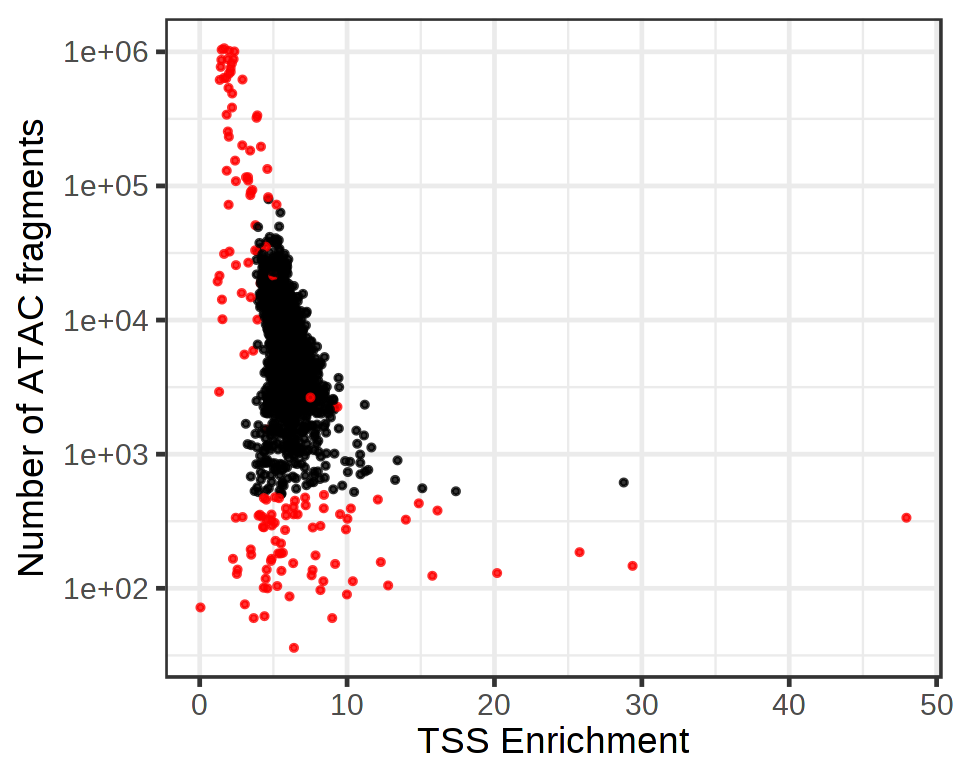

In [19]:
options(repr.plot.width = 8, repr.plot.height = 6.5)

ggplot(pbmc@meta.data,aes(x=TSS.enrichment ,y=atac_fragments, color=low_count_or_low_peak_targeting))+
    scale_color_manual(values=c("black","red"))+
    geom_point(size=1,alpha=0.8) +
    theme_bw(base_size=22)+
    scale_y_continuous(trans='log10')+xlab("TSS Enrichment")+ylab("Number of ATAC fragments")+NoLegend()


print("Min TSS enrichment after removing low count or low targeting barcodes: ")
print(min(pbmc@meta.data[!pbmc@meta.data$low_count_or_low_peak_targeting,'TSS.enrichment']))

#### **4.1.4. Fragment length and Nucleosome Signal**

So far, the QC metrics discussed above have focused on fragment counts. Another important QC metric unique to ATAC-seq is the fragment length. The fragment length can indicate whether a fragment originated from an open, nucleosome-free region of the genome or if it spans one or more nucleosomes.

The length of a nucleosome is 147 base pairs. Assuming that the transposase enzyme is not limiting, and that there is sufficient enzyme present to bind wherever there is an open region, short fragments (< 147 bp) arise from nucleosome-free regions, and longer fragments span one or more nucleosomes. Longer fragments can also arise from background tagmentation, where the transposase binds to DNA that is still wrapped around a nucleosome. Since the Epi Multiome assay is designed to capture open chromatin, it is expected that data from high-quality barcodes will be enriched for short fragments.

While a detailed analysis of fragment lengths is beyond the scope of this guide, Signac provides functionality to calculate a [`Nucleosome Signal`](https://stuartlab.org/signac/reference/nucleosomesignal) metric as the ratio of the number of mononucleosome fragments to the number of nucleosome-free fragments per barcode.

Similar to fraction fragments overlapping peaks, the nucleosome signal is a measure of how much ATAC data is arising from open regions of the chromatin. Specific targeting of open chromatin should yield fragments that are enriched in peaks and predominantly short, or nucleosome-free. Consequently, in the plot below, observe a clear inverse relationship between the nucleosome signal and the fraction fragments overlapping peaks.

- High-quality barcodes, clustered in the top left of this plot, have more short fragments that overlap peaks. These barcodes have lower values of nucleosome signal and higher values of fraction fragments overlapping peaks.

- Low-quality barcodes in the bottom right tail of the plot have a high nucleosome signal and a low fraction fragments overlapping peaks.

The previous low peak targeting threshold effectively filters out barcodes that have a high nucleosome signal.


In [20]:
pbmc <- NucleosomeSignal(pbmc)

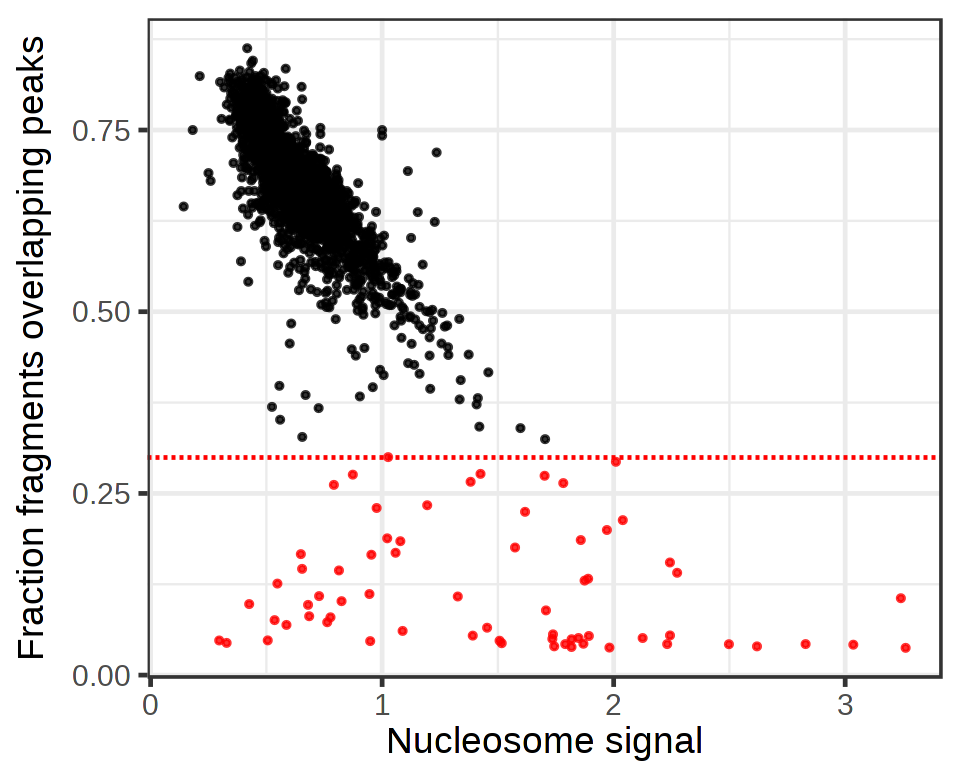

In [21]:
options(repr.plot.width = 8, repr.plot.height = 6.5)
ggplot(pbmc@meta.data,aes(x=nucleosome_signal ,y=frac_fragments_in_peaks, color=low_peak_targeting))+
    geom_point(size=1,alpha=0.8) +
    scale_color_manual(values=c("black","red"))+
    geom_hline(yintercept = low_peak_targeting_threshold,linetype='dashed',color='red')+
    theme_bw(base_size=22)+ylab("Fraction fragments overlapping peaks")+xlab("Nucleosome signal") + NoLegend()

#### **4.1.5 RNA and ATAC Coexpression**

Finally, look at the gene expression and ATAC data for each barcode. As described in section 4.1.1, Cell Ranger ARC may identify a barcode as a cell barcode if it has high ATAC signal, even if it has low gene expression signal. If the user is interested in only retaining barcodes that have high quality data in both modalities, you can additionally filter out barcodes with low gene expression signal.

The following code filters out barcodes with fewer than 500 gene expression UMIs.

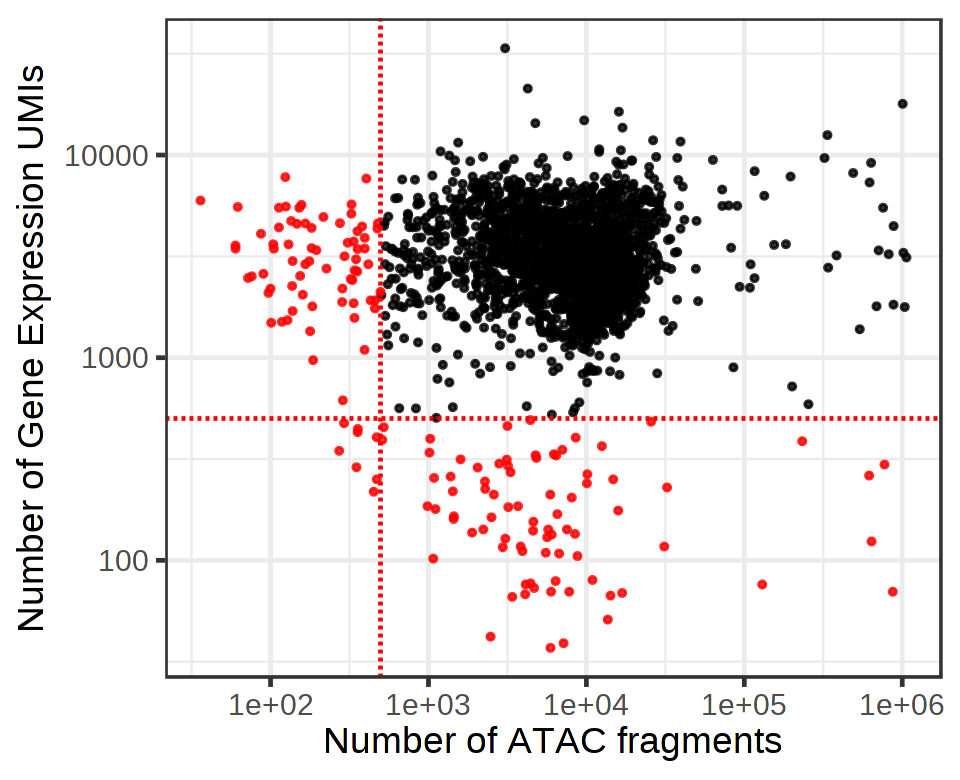

In [22]:
low_gene_expression_threshold = 500

pbmc@meta.data$low_gene_expr_or_low_atac = pbmc@meta.data$gex_umis_count<low_gene_expression_threshold | pbmc@meta.data$low_count

ggplot(pbmc@meta.data,aes(x=atac_fragments ,y=gex_umis_count, color = low_gene_expr_or_low_atac))+
    geom_point(size=1,alpha=0.8) +
    theme_bw(base_size=22)+xlab("Number of ATAC fragments")+ylab("Number of Gene Expression UMIs")+
    geom_vline(xintercept=low_fragment_count_threshold,linetype="dashed",color="red")+
    geom_hline(yintercept=low_gene_expression_threshold,linetype="dashed",color="red")+
    scale_color_manual(values=c("black","red"))+
    scale_y_continuous(trans='log10')+
    scale_x_continuous(trans='log10')+NoLegend()

#### **4.1.6 Putting it all together**

So far, several QC metrics have been introduced to evaluate the quality of your Epi Multiome data. As mentioned in the beginning of the guide, these metrics are interrelated, and a [linked notebook](https://colab.research.google.com/github/10XGenomics/analysis_guides/blob/main/Epi_multiome_QC_interactive_visualization.ipynb) is provided to emphasize the utility of evaluating these metrics in the context of one another.

The following code only retains barcodes with a high number of ATAC fragments, a high fraction fragments overlapping peaks, and a high number of gene expression UMIs.

In [23]:
pbmc_subset <- subset(x = pbmc,(frac_fragments_in_peaks > low_peak_targeting_threshold & atac_fragments > low_fragment_count_threshold & gex_umis_count > low_gene_expression_threshold))
dim(pbmc_subset)

[1] 81157  2823

### **4.2. Peak-level quality control**

In addition to exploring data quality at the level of barcodes, it is also useful to assess the quality of the peak calls. For example, repetitive regions of the genome are frequently collapsed down to a single region on the reference, creating a spurious pile-up of fragments and a false positive peak.

The [ENCODE exclusion list](https://www.nature.com/articles/s41598-019-45839-z), which is conveniently included in Signac, is a useful starting point to identify and filter out peaks in problematic regions of the genome. Note that the exclusion lists are genome-specific. The following code uses the exclusion list for Human GRCh38.

In [24]:
blacklist_hg38_unified

GRanges object with 910 ranges and 0 metadata columns:
        seqnames            ranges strand
           <Rle>         <IRanges>  <Rle>
    [1]     chr1     628903-635104      *
    [2]     chr1   5850087-5850571      *
    [3]     chr1   8909610-8910014      *
    [4]     chr1   9574580-9574997      *
    [5]     chr1 32043823-32044203      *
    ...      ...               ...    ...
  [906]     chrY 11290797-11334278      *
  [907]     chrY 11493053-11592850      *
  [908]     chrY 11671014-11671046      *
  [909]     chrY 11721528-11749472      *
  [910]     chrY 56694632-56889743      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [25]:
# use granges to extract peaks from Seurat object.
all_peaks = granges(pbmc)
all_peaks

GRanges object with 81157 ranges and 0 metadata columns:
            seqnames        ranges strand
               <Rle>     <IRanges>  <Rle>
      [1]       chr1    9782-10672      *
      [2]       chr1 180547-181446      *
      [3]       chr1 191121-191998      *
      [4]       chr1 267553-268447      *
      [5]       chr1 270906-271782      *
      ...        ...           ...    ...
  [81153] KI270711.1   22605-23472      *
  [81154] KI270713.1     3924-4839      *
  [81155] KI270713.1   21448-22354      *
  [81156] KI270713.1   26202-26986      *
  [81157] KI270713.1   36937-37838      *
  -------
  seqinfo: 37 sequences from an unspecified genome; no seqlengths

In [26]:
# Identify peaks that overlap with the exclusion list.
exclusionlist_overlap = findOverlaps(all_peaks, blacklist_hg38_unified)
exclusionlist_overlap

Hits object with 122 hits and 0 metadata columns:
        queryHits subjectHits
        <integer>   <integer>
    [1]         8           1
    [2]         9           1
    [3]      4308          23
    [4]      9180          66
    [5]      9181          66
    ...       ...         ...
  [118]     81108         906
  [119]     81109         906
  [120]     81110         906
  [121]     81111         906
  [122]     81112         910
  -------
  queryLength: 81157 / subjectLength: 910

Observe that 122 of our peaks are on the ENCODE exclusion list.

Next, look at an example of one of these in the [Integrative Genomics Viewer](https://igv.org/) (IGV).

To produce the screenshots below, the following Cell Ranger output files were loaded into IGV (click on any of the links below to see more details about each file):
1. [atac_possorted_bam.bam](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/outputs/atac-barcoded-bam) (and the associated .bai index): This is a position-sorted and indexed BAM file containing all ATAC library reads. By default, IGV hides reads that are flagged as duplicates, and therefore the view below shows us deduplicated reads, i.e., unique fragments. The BAM coverage track shows the fragment coverage across the genome.

3. [atac_cut_sites.bigwig](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/outputs/transposition-counts): This contains a track of smoothed cut sites across the genome. The track is used for peak calling. See the [companion article](https://docs.google.com/document/d/1fm898J2dsPXmIRlWyiG-yFbrpkQncCGzt5yhTocg8c4/edit?tab=t.0) for more details on the distinctions between cut sites and fragments and how these relate to peaks.
4. [atac_peaks.bed](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/outputs/peaks-file): This file contains the genomic coordinates for every identified peak. This appears at the bottom of the view shown.

Observe a very large pile-up of low-mapping-quality fragments and a noisy coverage track. This is an indicator that this peak is likely spurious. Centromeres and telomeres frequently have repeated satellite sequences, and collapsing these to single regions on the reference often leads to mapping artifacts.

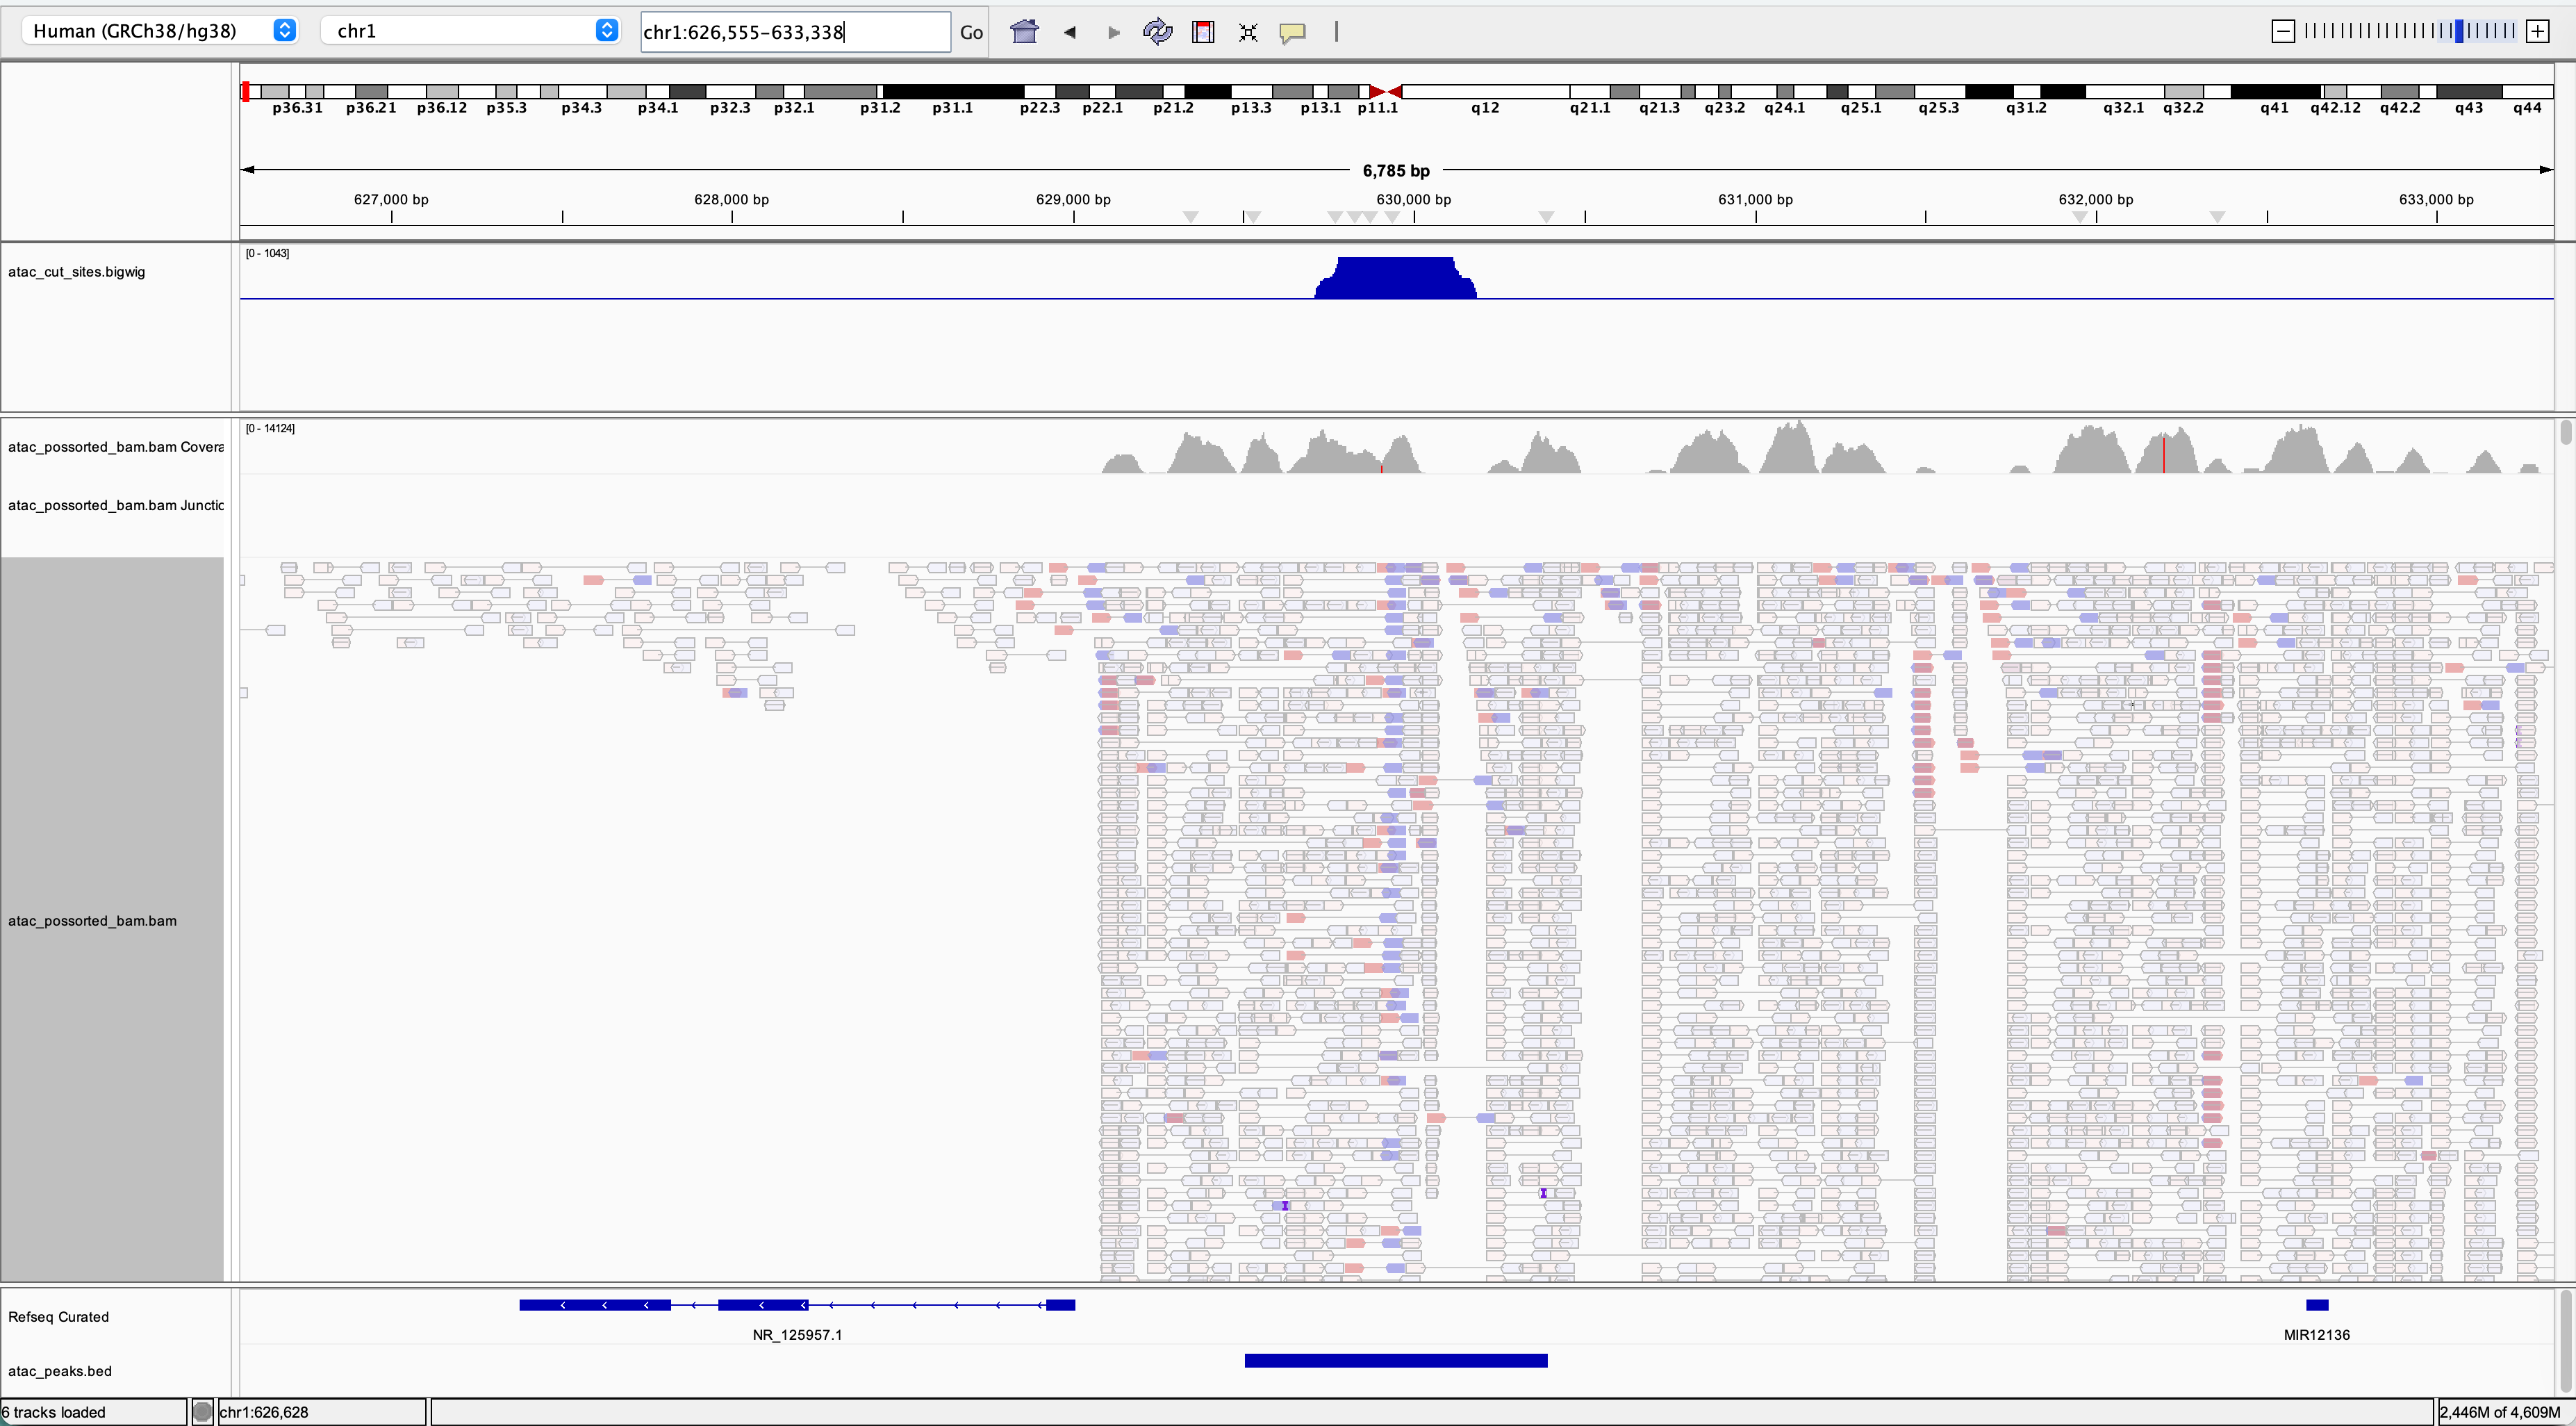

This is another example of a region on the ENCODE exclusion list, located at the centromere of chromosome 10. While there are not as many low-mapping-quality reads here, the coverage track is extremely noisy, and this peak is likely spurious.

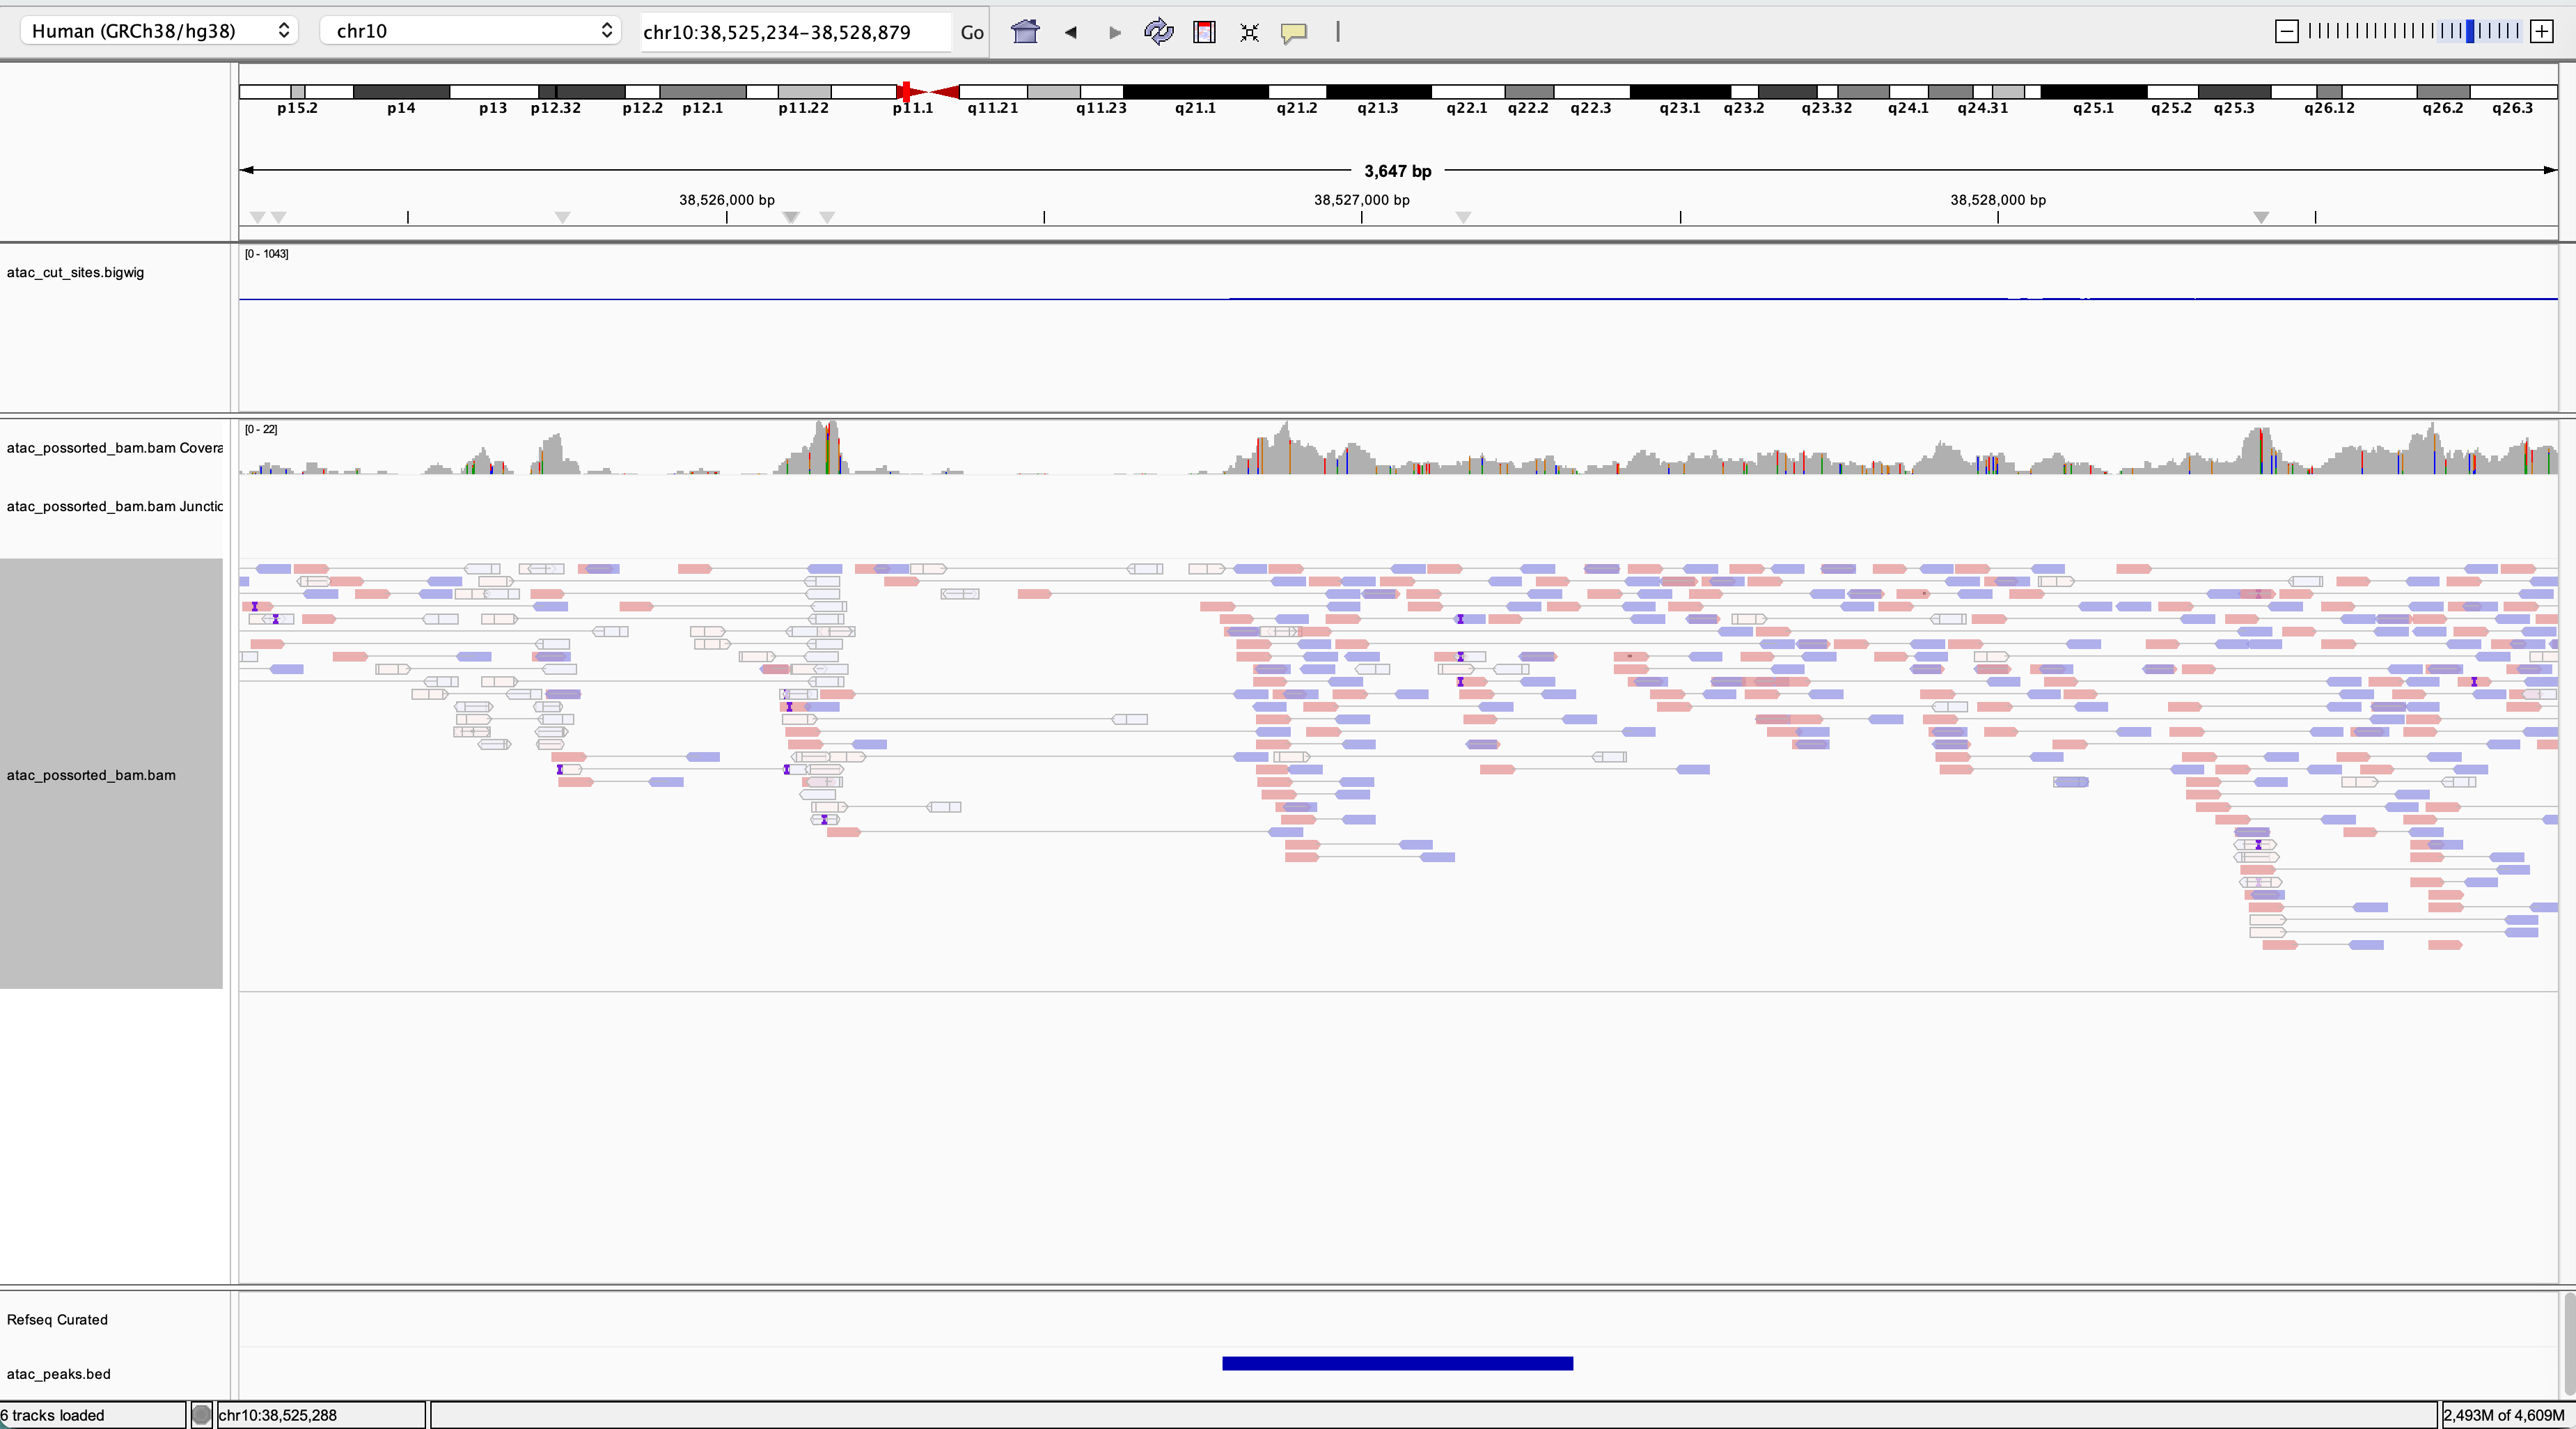

In contrast, the peaks overlapping ACTIN B show a large pile-up of high-map-quality fragments, and the peaks look clean and well-defined in the coverage track.

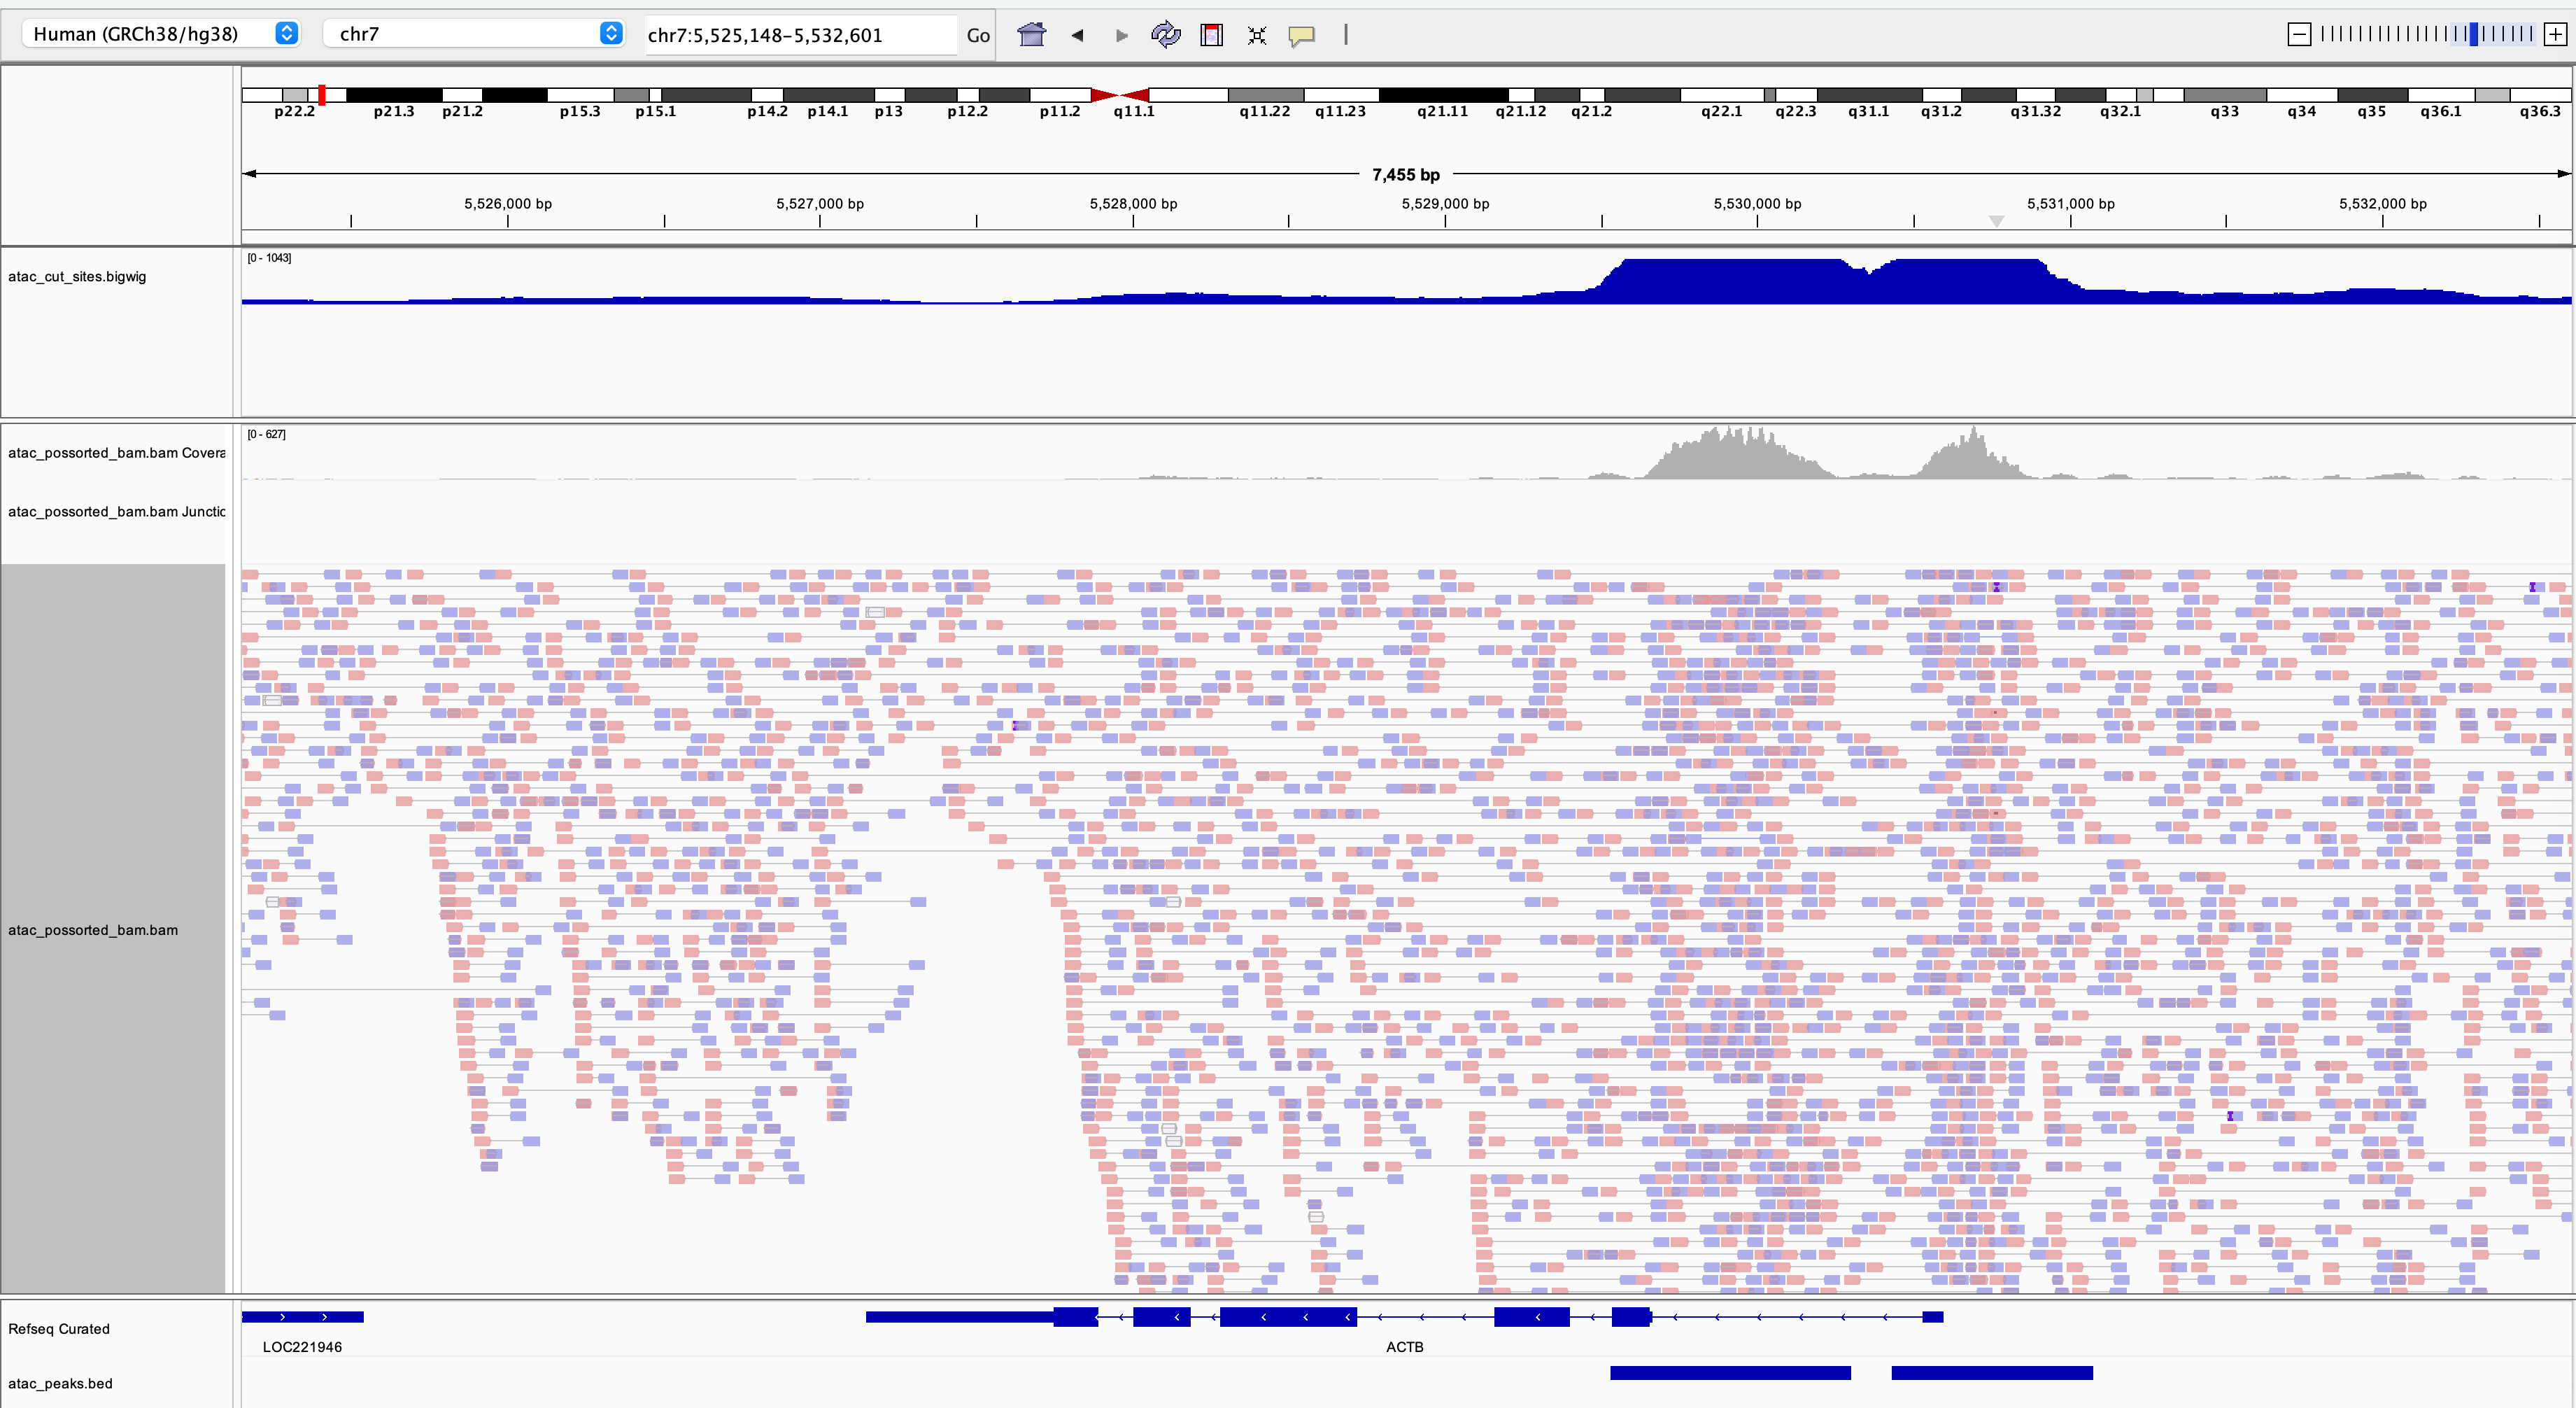

The following code removes any peaks that overlap with the ENCODE exclusion list:

In [27]:
peaks2keep = rownames(pbmc_subset@assays$ATAC)[!(all_peaks %in% all_peaks[queryHits(exclusionlist_overlap)])]
pbmc_subset@assays$ATAC <- subset(pbmc_subset@assays$ATAC, features = peaks2keep)

In a diploid organism, the true coverage per base pair from a single nucleus is <=2. However, technical artifacts such as ambient contamination, multiplets, and mismapping may increase the coverage at a given position. Setting a conservative threshold of 20 counts (cut sites/fragment ends) per peak per barcode, you can see that even post-filtering of the ENCODE exclusion list regions, there are entries in the count matrix that have high coverage. While further analysis is required to examine the cause of these artifacts, in this case, a large number of these arise from a single barcode at column 244 in the matrix. Visualizing some of these problematic regions for this particular barcode in IGV reveals several instances of a >2 per-base fragment pile-up across different chromosomes, and therefore the following code filters this barcode from further analyses.

In [28]:
anomalous_high_counts = which(pbmc_subset@assays$ATAC$counts>20,arr.ind=TRUE) # note that counts here are transposition events/fragment ends, not fragments.
anomalous_high_counts

,row,col
chr8-143609234-143610130,75361,93
chr1-174999310-175000208,5757,244
chr12-89709163-89709966,18407,244
chr18-12376952-12377846,34915,244
chr19-1406947-1407876,36217,244
chr19-5719952-5720852,36622,244
chr19-39341768-39342686,38446,244
chr2-676666-677659,40024,244
chr2-44168183-44168992,41297,244
chr2-207529416-207530330,45170,244


In [29]:
bc_freq = table(anomalous_high_counts[,2])
bc_indices = names(bc_freq)
bcs_to_remove = colnames(pbmc_subset@assays$ATAC)[as.numeric(names(bc_freq))[bc_freq>5]]
bcs_to_remove

[1] "ACCCGTAAGAGCCGCT-1"

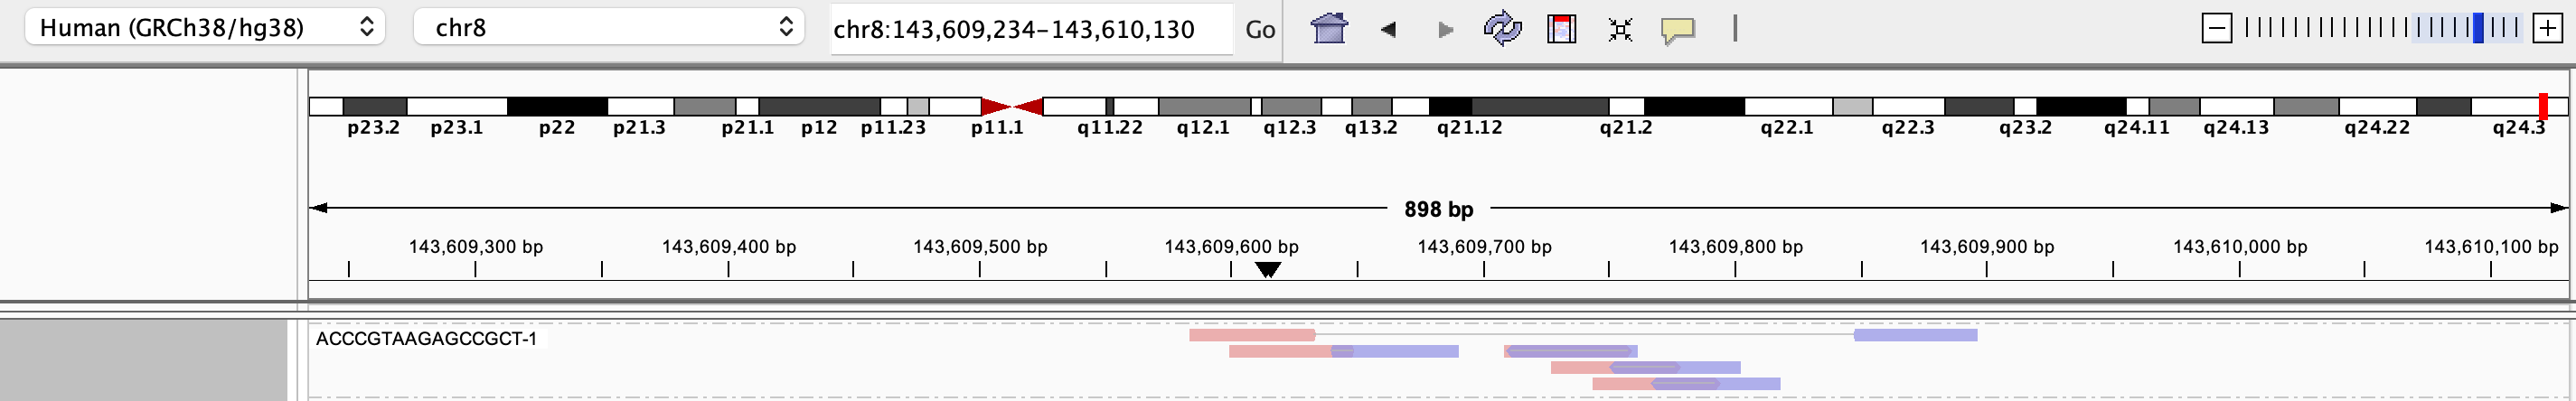

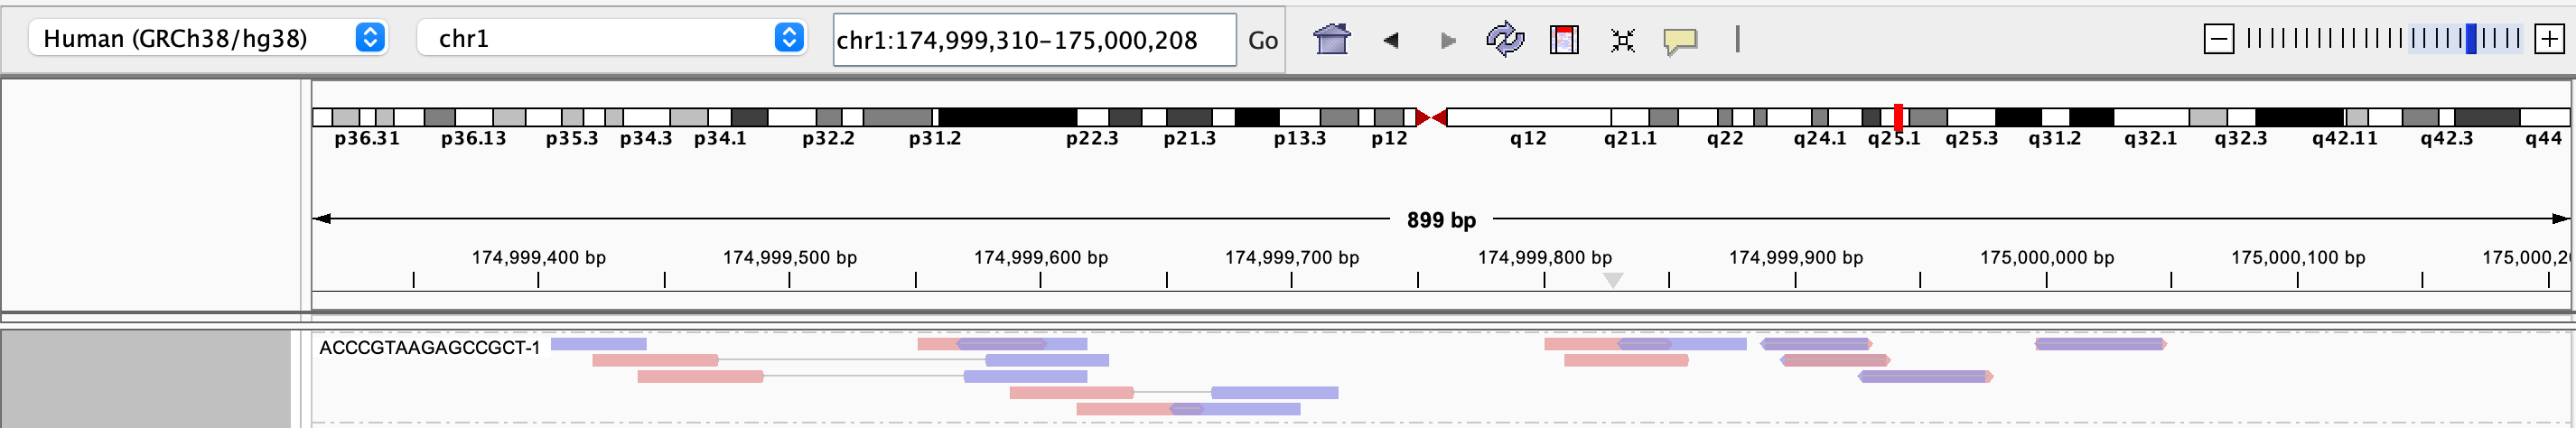

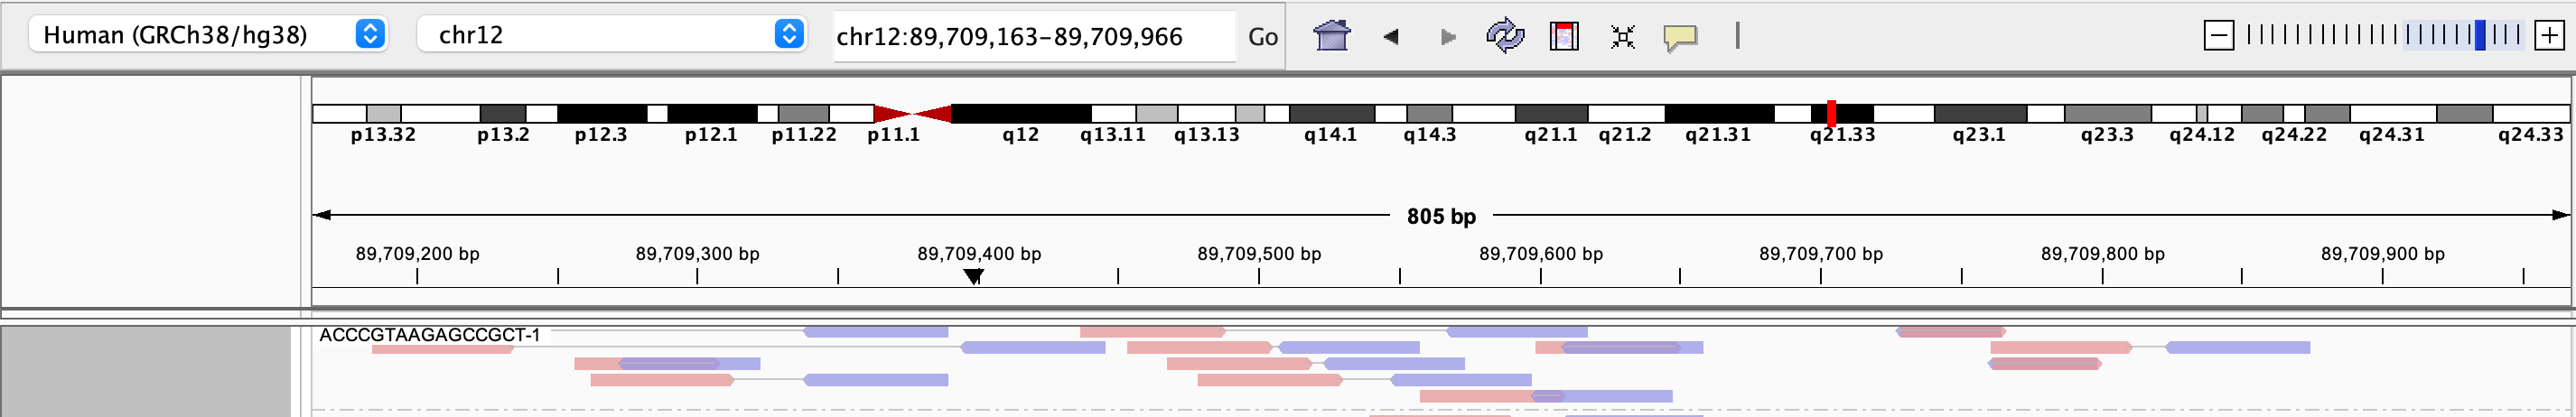

In [30]:
pbmc_subset <- subset(x = pbmc_subset,cells = colnames(pbmc_subset)[!(colnames(pbmc_subset) %in% bcs_to_remove)])

## **5. Normalization and Dimensionality Reduction with Seurat and Signac**


After filtering, you can run the standard normalization workflows for RNA and ATAC and visualize the data. In addition to visualizing UMAPs for the separate ATAC and RNA data, [Seurat's Weighted Nearest Neighbors algorithm](https://satijalab.org/seurat/articles/weighted_nearest_neighbor_analysis#wnn-analysis-of-10x-multiome-rna-atac) allows you to jointly visualize both modalities.

This step may take ~10 minutes to run.

In [31]:
DefaultAssay(pbmc_subset) <- "RNA"
pbmc_subset <-   SCTransform(pbmc_subset,verbose=FALSE)
pbmc_subset <- RunPCA(pbmc_subset,verbose=FALSE)
pbmc_subset <- FindNeighbors(pbmc_subset, dims = 1:30, reduction = "pca", graph.name = "RNA_nn", verbose = FALSE)

DefaultAssay(pbmc_subset) <- "ATAC"
pbmc_subset <- FindTopFeatures(pbmc_subset, min.cutoff = 5)
pbmc_subset <- RunTFIDF(pbmc_subset, verbose=FALSE)
pbmc_subset <- RunSVD(pbmc_subset, verbose=FALSE)
pbmc_subset <- FindNeighbors(pbmc_subset, dims = 2:50, reduction = "lsi", graph.name = "ATAC_nn", verbose = FALSE)

pbmc_subset <- FindMultiModalNeighbors(object = pbmc_subset,reduction.list = list("pca", "lsi"), dims.list = list(1:30, 2:50),verbose = FALSE)

pbmc_subset <- RunUMAP(object = pbmc_subset,nn.name = "weighted.nn",reduction.name="wnn",verbose=FALSE)

DefaultAssay(pbmc_subset) <- "ATAC"
pbmc_subset <- RunUMAP(object = pbmc_subset, dims = 2:50, reduction.name="umap_atac",verbose=FALSE)

DefaultAssay(pbmc_subset) <- "RNA"
pbmc_subset <- RunUMAP(object = pbmc_subset, dims = 1:30, reduction.name = "umap_rna",verbose=FALSE)

Only one graph name supplied, storing nearest-neighbor graph only

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :
"Some features contain 0 total counts"
Only one graph name supplied, storing nearest-neighbor graph only

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"


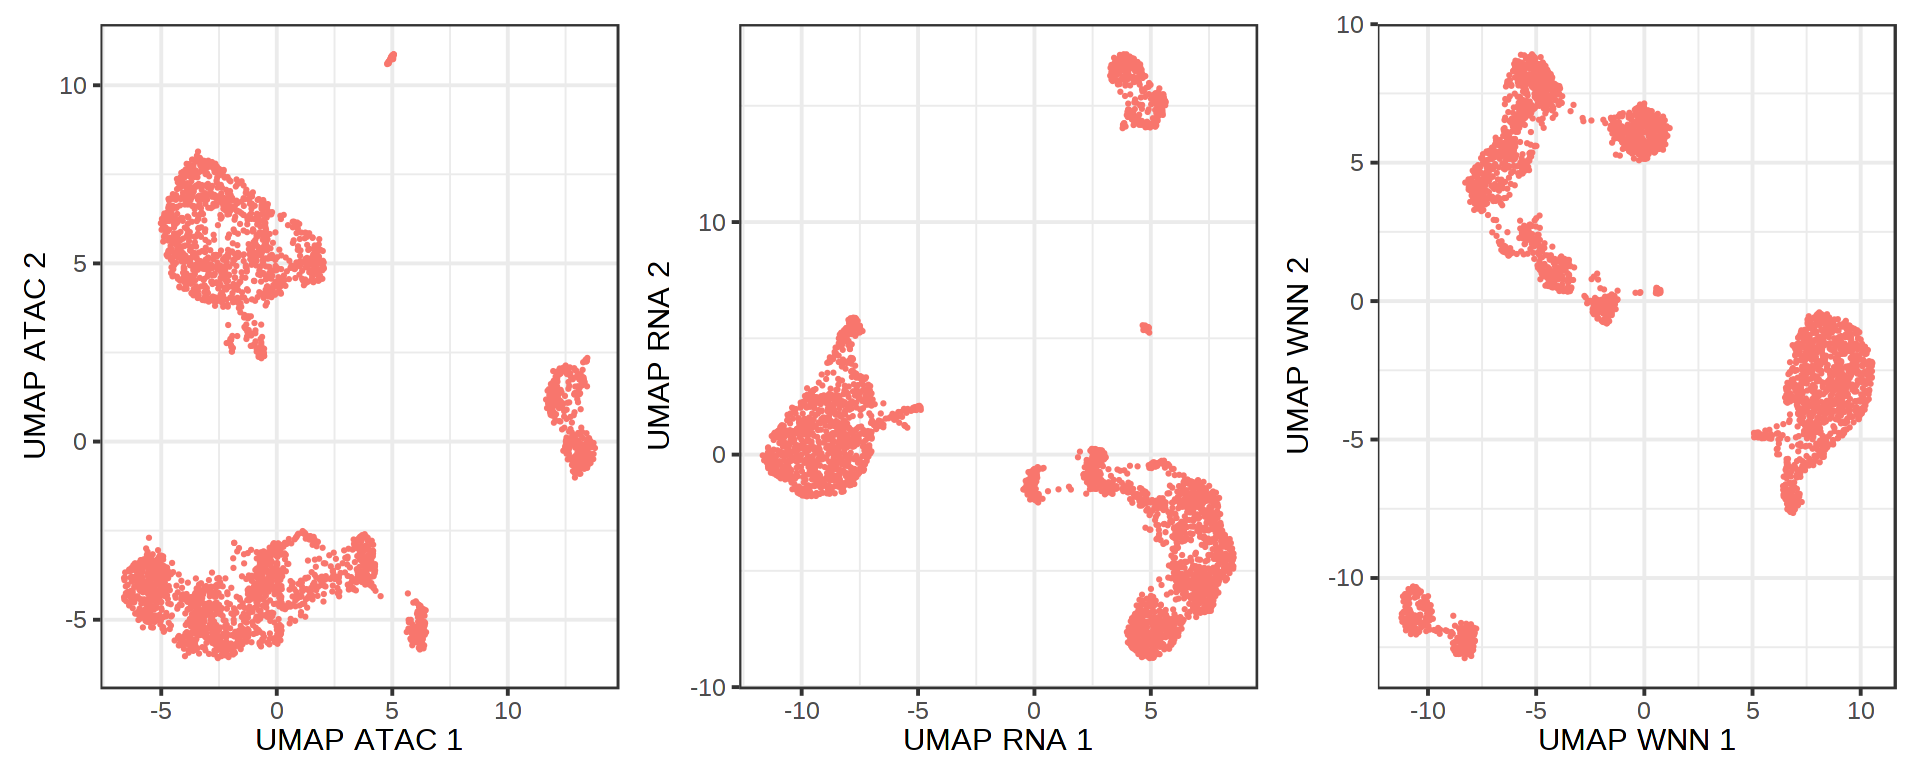

In [32]:
options(repr.plot.width = 16, repr.plot.height = 6.5)

g1 = DimPlot(pbmc_subset,reduction="umap_atac") +theme_bw(base_size=18) + NoLegend()+xlab("UMAP ATAC 1") + ylab("UMAP ATAC 2")
g2 = DimPlot(pbmc_subset,reduction="umap_rna") +theme_bw(base_size=18) + NoLegend()+xlab("UMAP RNA 1") + ylab("UMAP RNA 2")
g3 = DimPlot(pbmc_subset,reduction="wnn") +theme_bw(base_size=18)+ NoLegend()+xlab("UMAP WNN 1") + ylab("UMAP WNN 2")


g1+g2+g3

You can now visualize the major cell types from Cell Ranger ARC on the UMAPs below.

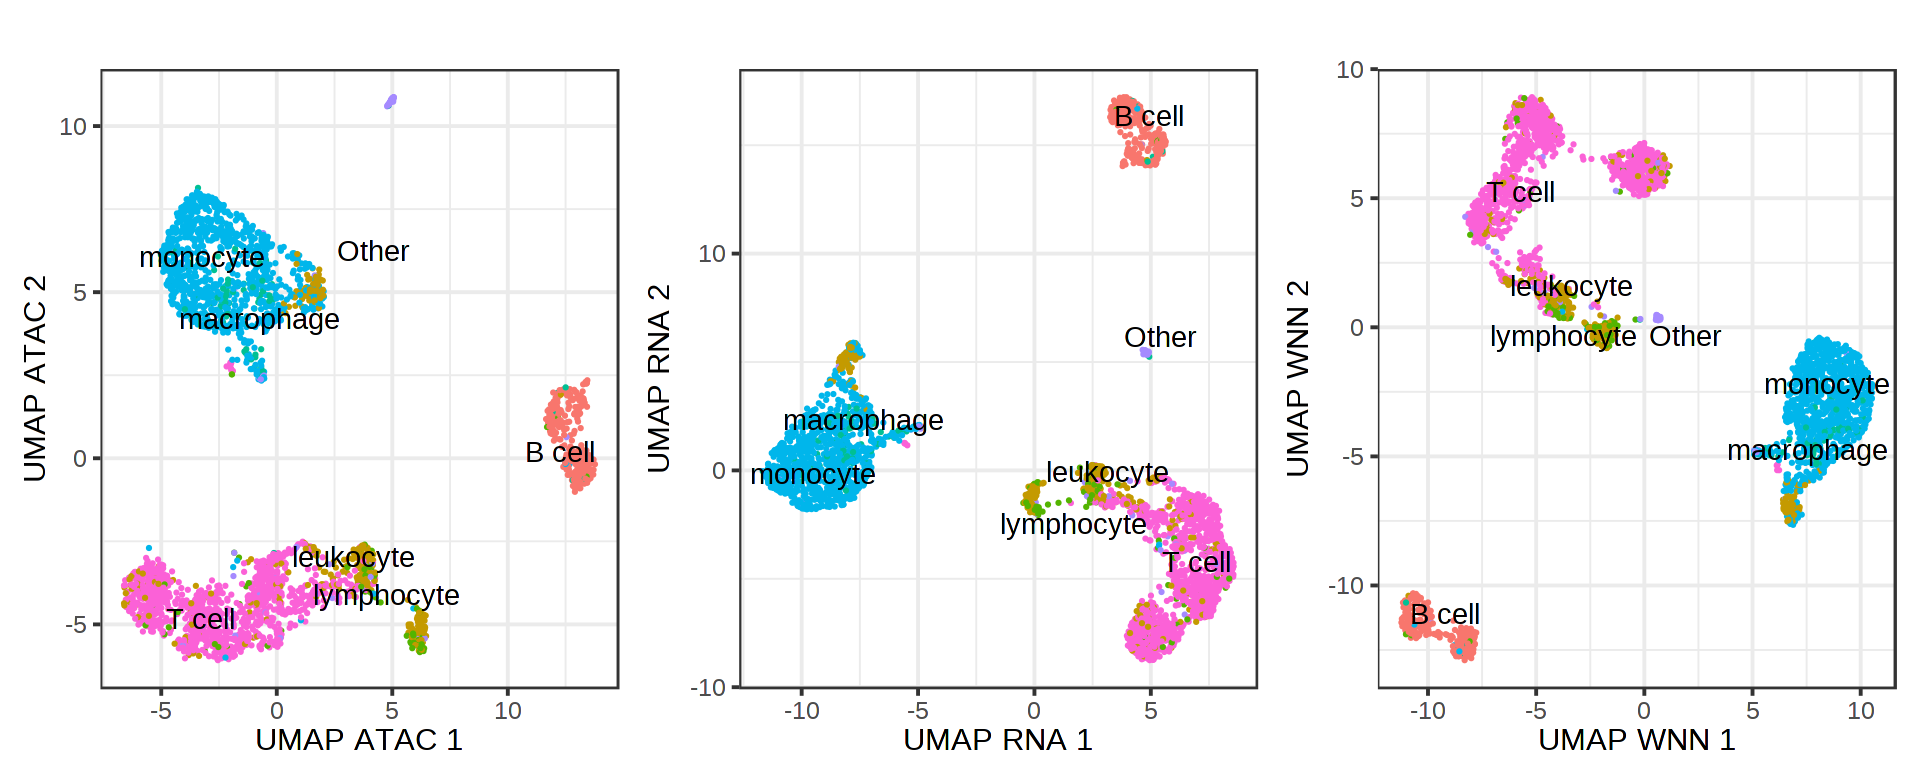

In [33]:
options(repr.plot.width = 16, repr.plot.height = 6.5)

g1 = DimPlot(pbmc_subset,reduction="umap_atac",group.by="cell_type",label=TRUE,label.size=6, repel=TRUE) +theme_bw(base_size=18) + ggtitle("") + NoLegend()+xlab("UMAP ATAC 1") + ylab("UMAP ATAC 2")
g2 = DimPlot(pbmc_subset,reduction="umap_rna",group.by="cell_type",label=TRUE,label.size=6, repel=TRUE) +theme_bw(base_size=18) + ggtitle("") + NoLegend()+xlab("UMAP RNA 1") + ylab("UMAP RNA 2")
g3 = DimPlot(pbmc_subset,reduction="wnn",group.by="cell_type",label=TRUE,label.size=6, repel=TRUE) +theme_bw(base_size=18)+ ggtitle("") + NoLegend()+xlab("UMAP WNN 1") + ylab("UMAP WNN 2")

g1+g2+g3

## **6. Conclusion**

This concludes the quality control portion of our analysis. This guide introduced several key quality metrics and applied heuristics to identify and mitigate the impact of biological noise and technical artifacts.

It is important to use the strategies outlined here as a starting point for exploring your own data, rather than adopting them as a set of prescriptive rules. This will enable you to interpret your data correctly in the context of your specific biological questions.

With the data now filtered and normalized, you are ready to transition to downstream analysis. The [companion article](https://www.10xgenomics.com/analysis-guides/getting-started-cell-ranger-arc) lists various tools and detailed examples for these integrated workflows, as well as more information on quality control of gene expression data.